#TP3 - Parte 2

##Literal 1

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# =============================================================================
# CARGAR DATOS
# =============================================================================
df_2005 = pd.read_excel('BaseInt_final.xlsx', sheet_name='Base2005')
df_2025 = pd.read_excel('BaseInt_final.xlsx', sheet_name='Base2025')

print(f"\nHoja 'Base2005' cargada: {df_2005.shape}")
print(f"Hoja 'Base2025' cargada: {df_2025.shape}")

print(f"\nTipos de datos:")
print(df_2005.dtypes.unique())


Hoja 'Base2005' cargada: (1062, 180)
Hoja 'Base2025' cargada: (1490, 239)

Tipos de datos:
[dtype('int64') dtype('O') dtype('float64')]


In [ ]:
# # =============================================================================
# # ANALIZAR COLUMNA ESTADO
# # =============================================================================
# print("\nValores únicos en 'estado' (Base2005):")
# print(df_2005['estado'].unique())

# print("\nDistribución de 'estado' (Base2005):")
# print(df_2005['estado'].value_counts())

# df_2025.rename(columns={'ESTADO': 'estado'}, inplace=True)

# print("\n\nDistribución de 'estado' (Base2025):")
# print(df_2025['estado'].value_counts())

# # Verificar si hay ESTADO = 0
# print(f"\n\nObservaciones con estado=0 en 2005: {(df_2005['estado'] == 0).sum()}")
# print(f"Observaciones con estado=0 en 2025: {(df_2025['estado'] == 0).sum()}")



Valores únicos en 'estado' (Base2005):
['Ocupado' 'Inactivo' 'Menor de 10 años' 'Desocupado']

Distribución de 'estado' (Base2005):
estado
Inactivo            457
Ocupado             431
Menor de 10 años    122
Desocupado           52
Name: count, dtype: int64


Distribución de 'estado' (Base2025):
estado
1    642
3    630
4    163
2     55
Name: count, dtype: int64


Observaciones con estado=0 en 2005: 0
Observaciones con estado=0 en 2025: 0


In [ ]:
# Para respondieron_2005
# df_2005['desocupado'] = (df_2005['estado'] == 'Desocupado').astype(int)

print("\nVariable 'desocupado' en respondieron_2005:")
print("  0 = No desocupado (Ocupado, Inactivo, Menor de 10 años)")
print("  1 = Desocupado")

print(f"\nDistribución:")
print(df_2005['desocupado'].value_counts())
print(f"\nProporción:")
print(df_2005['desocupado'].value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))


Variable 'desocupado' en respondieron_2005:
  0 = No desocupado (Ocupado, Inactivo, Menor de 10 años)
  1 = Desocupado

Distribución:
desocupado
0    1010
1      52
Name: count, dtype: int64

Proporción:
desocupado
0    95.10%
1     4.90%
Name: proportion, dtype: object


In [ ]:
# Columnas a excluir
columnas_excluir = ['desocupado', 'estado', 'CODUSU', 'nro_hogar', 'componente']


# Preparar X e y para respondieron_2005
X_respondieron_2005 = df_2005.drop(columns=[col for col in columnas_excluir if col in df_2005.columns])
y_respondieron_2005 = df_2005['desocupado']

print(f"\nShape inicial de X_respondieron_2005: {X_respondieron_2005.shape}")
print(f"Shape de y_respondieron_2005: {y_respondieron_2005.shape}")

print(f"\nConvirtiendo columnas categóricas a dummies...")
X_respondieron_2005 = pd.get_dummies(X_respondieron_2005)
print(f"Nuevas dimensiones: {X_respondieron_2005.shape}")


# Agregar columna de unos (intercepto) al inicio
X_respondieron_2005.insert(0, 'intercepto', 1)

print(f"\n\nX_respondieron_2005 final:")
print(f"  - Shape: {X_respondieron_2005.shape}")
print(f"  - Número de features: {X_respondieron_2005.shape[1]} (incluyendo intercepto)")
print(f"  - Columnas (primeras 10): {X_respondieron_2005.columns.tolist()[:10]}")



Shape inicial de X_respondieron_2005: (1062, 175)
Shape de y_respondieron_2005: (1062,)

Convirtiendo columnas categóricas a dummies...
Nuevas dimensiones: (1062, 531)


X_respondieron_2005 final:
  - Shape: (1062, 532)
  - Número de features: 532 (incluyendo intercepto)
  - Columnas (primeras 10): ['intercepto', 'ano4', 'pondera', 'ch14', 'ch15_cod', 'ch16_cod', 'pp03d', 'pp3e_tot', 'pp3f_tot', 'pp04b_cod']


In [ ]:
# Columnas a excluir
columnas_excluir = ['desocupado', 'estado', 'CODUSU', 'NRO_HOGAR', 'COMPONENTE']


# Preparar X e y para respondieron_2005
X_respondieron_2025 = df_2025.drop(columns=[col for col in columnas_excluir if col in df_2025.columns])
y_respondieron_2025 = df_2025['desocupado']

print(f"\nShape inicial de X_respondieron_2005: {X_respondieron_2025.shape}")
print(f"Shape de y_respondieron_2005: {y_respondieron_2025.shape}")

print(f"\nConvirtiendo columnas categóricas a dummies...")
X_respondieron_2025 = pd.get_dummies(X_respondieron_2025)
print(f"Nuevas dimensiones: {X_respondieron_2025.shape}")



# Agregar columna de unos (intercepto) al inicio
X_respondieron_2025.insert(0, 'intercepto', 1)

print(f"\n\nX_respondieron_2005 final:")
print(f"  - Shape: {X_respondieron_2025.shape}")
print(f"  - Número de features: {X_respondieron_2025.shape[1]} (incluyendo intercepto)")
print(f"  - Columnas (primeras 10): {X_respondieron_2025.columns.tolist()[:10]}")


Shape inicial de X_respondieron_2005: (1490, 235)
Shape de y_respondieron_2005: (1490,)

Convirtiendo columnas categóricas a dummies...
Nuevas dimensiones: (1490, 235)


X_respondieron_2005 final:
  - Shape: (1490, 236)
  - Número de features: 236 (incluyendo intercepto)
  - Columnas (primeras 10): ['intercepto', 'ANO4', 'TRIMESTRE', 'H15', 'REGION', 'AGLOMERADO', 'PONDERA', 'CH03', 'CH04', 'CH05']


In [ ]:
X_train_2005, X_test_2005, y_train_2005, y_test_2005 = train_test_split(
    X_respondieron_2005,
    y_respondieron_2005,
    test_size=0.30,
    random_state=101,
)

X_train_2025, X_test_2025, y_train_2025, y_test_2025 = train_test_split(
    X_respondieron_2025,
    y_respondieron_2025,
    test_size=0.30,
    random_state=101,
)



## Literal 2

In [ ]:
# Inicializar modelos

lr_2005 = LogisticRegression(random_state=101, max_iter=1000)
lda_2005 = LinearDiscriminantAnalysis()
nb_2005 = GaussianNB()

modelos_2005 = {
    'Regresión Logística': lr_2005,
    'Análisis Discriminante Lineal': lda_2005,
    'Naive Bayes': nb_2005
}

print("Modelos inicializados:")
for nombre in modelos_2005.keys():
    print(f"  - {nombre}")

# Entrenar cada modelo
print("\n\nEntrenando modelos...")
for nombre, modelo in modelos_2005.items():
    print(f"\nEntrenando: {nombre}...")
    modelo.fit(X_train_2005, y_train_2005)
    print(f"  ✓ {nombre} entrenado")

print("\n✓ Todos los modelos de 2005 entrenados exitosamente")

Modelos inicializados:
  - Regresión Logística
  - Análisis Discriminante Lineal
  - Naive Bayes


Entrenando modelos...

Entrenando: Regresión Logística...
  ✓ Regresión Logística entrenado

Entrenando: Análisis Discriminante Lineal...
  ✓ Análisis Discriminante Lineal entrenado

Entrenando: Naive Bayes...
  ✓ Naive Bayes entrenado

✓ Todos los modelos de 2005 entrenados exitosamente


In [ ]:
lr_2025 = LogisticRegression(random_state=101, max_iter=1000)
lda_2025 = LinearDiscriminantAnalysis()
nb_2025 = GaussianNB()

modelos_2025 = {
    'Regresión Logística': lr_2025,
    'Análisis Discriminante Lineal': lda_2025,
    'Naive Bayes': nb_2025
}

print("Modelos inicializados:")
for nombre in modelos_2025.keys():
    print(f"  - {nombre}")

# Entrenar cada modelo
print("\n\nEntrenando modelos...")
for nombre, modelo in modelos_2025.items():
    print(f"\nEntrenando: {nombre}...")
    modelo.fit(X_train_2025, y_train_2025)
    print(f"  ✓ {nombre} entrenado")

print("\n✓ Todos los modelos de 2025 entrenados exitosamente")

Modelos inicializados:
  - Regresión Logística
  - Análisis Discriminante Lineal
  - Naive Bayes


Entrenando modelos...

Entrenando: Regresión Logística...
  ✓ Regresión Logística entrenado

Entrenando: Análisis Discriminante Lineal...
  ✓ Análisis Discriminante Lineal entrenado

Entrenando: Naive Bayes...
  ✓ Naive Bayes entrenado

✓ Todos los modelos de 2025 entrenados exitosamente


AUC: 1.0000


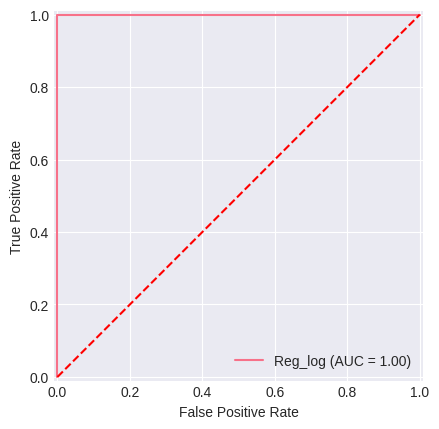

Confusion Matrix:
[[302   0]
 [  2  15]]
Accuracy Score: 0.9937304075235109


In [ ]:
# 2005 RL
y_test_pred_score_2005 = lr_2005.predict_proba(X_test_2005)[:,1]
y_test_pred_2005 = lr_2005.predict(X_test_2005)
auc = roc_auc_score(y_test_2005, y_test_pred_score_2005)
print('AUC: %.4f' % auc)
fpr, tpr, thresholds = roc_curve(y_test_2005, y_test_pred_score_2005)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name='Reg_log')
display.plot()
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.show()

matriz_confusion = confusion_matrix(y_test_2005, y_test_pred_2005)

print('Confusion Matrix:')
print(matriz_confusion)
print('Accuracy Score:', accuracy_score(y_test_2005, y_test_pred_2005))

AUC: 0.7290


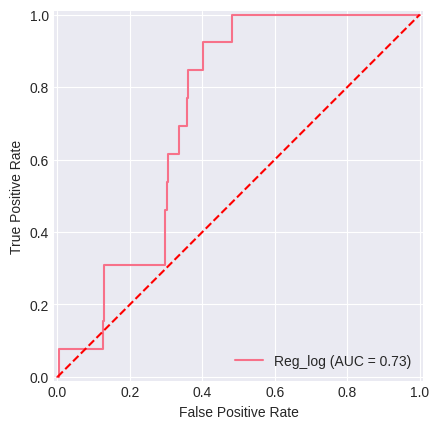

Confusion Matrix:
[[433   1]
 [ 13   0]]
Accuracy Score: 0.9686800894854586


In [ ]:
# 2025 RL

y_test_pred_score_2025 = lr_2025.predict_proba(X_test_2025)[:,1]
y_test_pred_2025 = lr_2025.predict(X_test_2025)
auc = roc_auc_score(y_test_2025, y_test_pred_score_2025)
print('AUC: %.4f' % auc)
fpr, tpr, thresholds = roc_curve(y_test_2025, y_test_pred_score_2025)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name='Reg_log')
display.plot()
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.show()

matriz_confusion = confusion_matrix(y_test_2025, y_test_pred_2025)

print('Confusion Matrix:')
print(matriz_confusion)
print('Accuracy Score:', accuracy_score(y_test_2025, y_test_pred_2025))

In [ ]:
#2005 A discriminante
X_r_2005 = lda_2005.transform(X_train_2005)


In [ ]:
#2005 A discriminante
y_test_pred_lda_2005 = lda_2005.predict(X_test_2005)
accuracy_lda_2005 = accuracy_score(y_test_2005, y_test_pred_lda_2005)
print("La exactitud del modelo es: %.2f" %accuracy_lda_2005)
plt.show()

La exactitud del modelo es: 1.00


In [ ]:
#2025 A discriminante
X_r_2025 = lda_2025.transform(X_train_2025)
y_test_pred_lda_2025 = lda_2025.predict(X_test_2025)
accuracy_lda_2025 = accuracy_score(y_test_2025, y_test_pred_lda_2025)
print("La exactitud del modelo es: %.2f" %accuracy_lda_2025)
plt.show()



La exactitud del modelo es: 1.00


In [ ]:
#2005
# Vamos a probar con distintos tamaños de k (cantidad de vecinos)
k_range = range(1,10)
scores = {}      # Para guardar la accuracy en un diccionario
scores_list = [] # Para guardar la accuracy en una lista
for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_2005, y_train_2005)
        y_pred_knn_2005 = knn.predict(X_test_2005)
        scores[k] = accuracy_score(y_test_2005, y_pred_knn_2005)
        scores_list.append(accuracy_score(y_test_2005, y_pred_knn_2005))
scores

{1: 0.9310344827586207,
 2: 0.9435736677115988,
 3: 0.9404388714733543,
 4: 0.9467084639498433,
 5: 0.9467084639498433,
 6: 0.9467084639498433,
 7: 0.9467084639498433,
 8: 0.9467084639498433,
 9: 0.9467084639498433}

In [ ]:
# k=3
knn_2005 = KNeighborsClassifier(n_neighbors=3)
knn_2005.fit(X_train_2005, y_train_2005)
y_test_pred_knn_2005 = knn_2005.predict(X_test_2005)
accuracy_knn = accuracy_score(y_test_2005, y_test_pred_knn_2005)
print("La exactitud del modelo es: %.3f" %accuracy_knn)

La exactitud del modelo es: 0.940


In [ ]:
#2025
# Vamos a probar con distintos tamaños de k (cantidad de vecinos)
k_range = range(1,10)
scores = {}      # Para guardar la accuracy en un diccionario
scores_list = [] # Para guardar la accuracy en una lista
for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_2025, y_train_2025)
        y_pred_knn_2025 = knn.predict(X_test_2025)
        scores[k] = accuracy_score(y_test_2025, y_pred_knn_2025)
        scores_list.append(accuracy_score(y_test_2025, y_pred_knn_2025))
scores

{1: 0.9485458612975392,
 2: 0.970917225950783,
 3: 0.9686800894854586,
 4: 0.970917225950783,
 5: 0.970917225950783,
 6: 0.970917225950783,
 7: 0.970917225950783,
 8: 0.970917225950783,
 9: 0.970917225950783}

In [ ]:
# k=3
knn_2025 = KNeighborsClassifier(n_neighbors=3)
knn_2025.fit(X_train_2025, y_train_2025)
y_test_pred_knn_2025 = knn_2025.predict(X_test_2025)
accuracy_knn = accuracy_score(y_test_2025, y_test_pred_knn_2025)
print("La exactitud del modelo es: %.3f" %accuracy_knn)

La exactitud del modelo es: 0.969


In [ ]:
# 2005

y_pred_nb_2005 = nb_2005.predict(X_test_2005)
accuracy_nb = accuracy_score(y_test_2005, y_pred_nb_2005)
print("La exactitud del modelo es: %.3f" %accuracy_nb)


La exactitud del modelo es: 0.969


In [ ]:
# 2025

y_pred_nb_2025 = nb_2025.predict(X_test_2025)
accuracy_nb_2025 = accuracy_score(y_test_2025, y_pred_nb_2025)
print("La exactitud del modelo es: %.3f" %accuracy_nb_2025)


La exactitud del modelo es: 0.555
